## Critical scenrio analysis

##### 1. Critical scenario in failure zone

In [17]:
from pathlib import Path
import sys, json
import numpy as np
from scipy.stats import norm
from scipy.spatial import cKDTree
from gurobipy import Model, GRB, quicksum
import hashlib 
import re

REPO_ROOT = Path(r"C:\Users\Minji Kang\Documents\GitHub\railnet_opt")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from inputs import input_files_kor, input_files_uk

REGION  = "uk"            # "kor" or "uk"
avg_velo = 149.0          # km/h
delay    = 180.0          # minutes
extra_m  = (avg_velo * delay / 60.0) * 1000.0
PDM_LIST = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
LAMBDA = 1.0
EPS = 1e-12
TOL = 1e-9
MATCH_R = 2e-4
MATCH_ABS = (5e-5, 5e-5)

read_json = lambda p: json.loads(Path(p).read_text(encoding="utf-8"))
to_tuple  = lambda d: {k: tuple(v) for k, v in d.items()}


input_files = input_files_kor if REGION == "kor" else input_files_uk

_nodes_raw = read_json(input_files["nodes"])
nodes = {nid: (v["x"], v["y"]) for nid, v in _nodes_raw.items()}
_edges_raw = read_json(input_files["edges"])
edges = {eid: (v["from"], v["to"]) for eid, v in _edges_raw.items()}
arcs = list(edges.values())

arc_distance = {
    eid: float(v["arc_distance"])
    for eid, v in _edges_raw.items()
    if "arc_distance" in v
}
intact_capacity = {
    eid: float(v["intact_capacity"])
    for eid, v in _edges_raw.items()
    if "intact_capacity" in v
}

demand_raw  = read_json(input_files["demand"])
demand_dict = {
    f"k{i+1}": {
        "origin":      r["origin_name"],
        "destination": r["destination_name"],
        "amount":      float(r["journeys"]),
        "distance":    float(r["distance"]),
    }
    for i, r in enumerate(demand_raw)
}
max_distance = {k: v["distance"] + extra_m for k, v in demand_dict.items()}


In [18]:
def beta_thr(pi: float, pdm: float, lam: float = 1.0) -> float:
    c = 1.0 - pi
    if c <= EPS:
        return np.nan
    x = pdm / (lam * c)
    if not (0.0 < x < 1.0):
        return np.nan
    return -norm.ppf(x)

def load_last_gen(path: Path):
    data = json.loads(path.read_text(encoding="utf-8"))
    last = data["generations"][-1]
    pareto = last.get("pareto", []) or []
    pop    = last.get("population", []) or []
    P = [{"pi": float(r["pi"]), "beta": float(r["beta"]), "failed": r.get("failed", None)} for r in pareto]
    Q = [{"pi": float(r["pi"]), "beta": float(r["beta"]), "failed": r.get("failed", []) or []} for r in pop]
    return P, Q

def backfill_failed_from_population(pareto, population,
                                    match_r: float = 2e-4,
                                    match_abs = (5e-5, 5e-5)):
    if not population:
        return [p.copy() for p in pareto]

    pop_xy = np.array([(r["pi"], r["beta"]) for r in population], float)
    tree   = cKDTree(pop_xy)

    out = []
    for p in pareto:
        pi, be = p["pi"], p["beta"]
        failed = p.get("failed", None)
        if failed is None:
            idxs = tree.query_ball_point([pi, be], r=match_r)
            chosen = None
            for idx in idxs:
                if abs(population[idx]["pi"] - pi) <= match_abs[0] and abs(population[idx]["beta"] - be) <= match_abs[1]:
                    chosen = population[idx]
                    break
            if chosen is not None:
                failed = chosen.get("failed", None)
        out.append({"pi": pi, "beta": be, "failed": failed})
    return out


In [19]:
import sys
sys.path.insert(0, r"C:\Users\Minji Kang\Documents\GitHub\railnet_opt")

from pathlib import Path
import numpy as np

from inputs import get_ga_files  
files = get_ga_files(REGION)

print("=== Pareto-only (backfilled): raw failed sequences INSIDE each threshold ===")
for label, path in files:
    if not path.exists():
        print(f"\n[WARN] missing: {path}")
        continue

    pareto, pop = load_last_gen(path)
    P = backfill_failed_from_population(pareto, pop)

    print(f"\n[{REGION.upper()} | {label}] pareto points = {len(P)}")
    pis   = np.array([r["pi"]   for r in P], float)
    betas = np.array([r["beta"] for r in P], float)

    for pdm in PDM_LIST:
        inside_idx = []
        for i, (pi, beta) in enumerate(zip(pis, betas)):
            thr = beta_thr(pi, pdm, LAMBDA)
            if not np.isnan(thr) and (beta - TOL <= thr):
                inside_idx.append(i)

        print(f"  PDM={pdm:.0e}  inside_count={len(inside_idx)}")
        for i in inside_idx:
            seq = P[i].get("failed", None)
            print(f"    ({i:3d}) pi={P[i]['pi']:.6f}, beta={P[i]['beta']:.6f}  ->  {seq}")


=== Pareto-only (backfilled): raw failed sequences INSIDE each threshold ===

[UK | delay30] pareto points = 48
  PDM=1e-01  inside_count=0
  PDM=1e-02  inside_count=0
  PDM=1e-03  inside_count=3
    ( 41) pi=0.891664, beta=2.035108  ->  [91, 101]
    ( 42) pi=0.935283, beta=2.034479  ->  [10, 11]
    ( 43) pi=0.980299, beta=1.128284  ->  [100]
  PDM=1e-04  inside_count=10
    ( 36) pi=0.883215, beta=2.860165  ->  [66, 91, 101]
    ( 37) pi=0.889246, beta=2.780803  ->  [91, 100, 101]
    ( 38) pi=0.889750, beta=2.768490  ->  [13, 91, 101]
    ( 39) pi=0.889847, beta=2.742567  ->  [11, 91, 101]
    ( 40) pi=0.891654, beta=2.734321  ->  [50, 91, 101]
    ( 41) pi=0.891664, beta=2.035108  ->  [91, 101]
    ( 42) pi=0.935283, beta=2.034479  ->  [10, 11]
    ( 43) pi=0.980299, beta=1.128284  ->  [100]
    ( 44) pi=0.998087, beta=1.104907  ->  [13]
    ( 45) pi=0.998184, beta=1.055055  ->  [11]
  PDM=1e-05  inside_count=15
    ( 31) pi=0.804746, beta=3.842460  ->  [13, 14, 16, 91, 101]
    (

##### 2. Critical scenario simulation
- Simulate a disruption in one of the critical scenarios and optimize the network.
- Plot the demand affected by the disruption.

2.1. utility 1

In [20]:
def make_arc_capacity(intact_capacity_dict, failed_eids, fail_cap=0.0, all_edge_ids=None):
    """Set capacity=fail_cap for failed_eids, else intact capacity (missing→0)."""
    keys = all_edge_ids if all_edge_ids is not None else intact_capacity_dict.keys()
    return {
        eid: (fail_cap if eid in failed_eids else float(intact_capacity_dict.get(eid, 0.0)))
        for eid in keys
    }

def safe_pi(total_dem: float, eloss: float, tol: float = 1e-12) -> float:
    if not total_dem or eloss is None or total_dem <= 0:
        return 0.0
    num = total_dem - eloss
    if abs(num) <= tol * max(1.0, total_dem):
        num = 0.0
    return float(np.clip(num / total_dem, 0.0, 1.0))

def MCNF_systemfunc_bubblechart(
    arcs, edges, arc_capacity, demand, max_distance, arc_distance, avg_velo: float = 149.0
):
    """Solve MCNF and return (expected_loss, total_demand_pd, unmet_table)."""
    edge_map = {v: k for k, v in edges.items()}

    T0, T1, T2, T3 = 15.0, 30.0, 60.0, 120.0
    DELTAS = [0.0, T0, T1, T2, T3]
    GAMMAS = [0.0, 0.25, 0.50, 0.75, 1.0]
    MCOUNT = len(DELTAS)
    ALPHA = 60.0 / (1000.0 * avg_velo)

    model = Model("MCNF"); model.Params.OutputFlag = 0
    flow, unmet, delta, gamma, lam = {}, {}, {}, {}, {}
    nodes_set = set(n for a in arcs for n in a)

    for k in demand:
        unmet[k]  = model.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f"u[{k}]")
        delta[k]  = model.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f"delta[{k}]")
        gamma[k]  = model.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f"gamma[{k}]")
        for m in range(MCOUNT):
            lam[k, m] = model.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f"lam[{k},{m}]")
        for (i, j) in arcs:
            eid = edge_map.get((i, j))
            cap = float(arc_capacity.get(eid, 0.0))
            flow[k, i, j] = model.addVar(lb=0.0, ub=cap, vtype=GRB.CONTINUOUS, name=f"f[{k},{i},{j}]")

    model.update()

    out_o, dist_sum = {}, {}
    for k, info in demand.items():
        o = info["origin"]
        out_o[k] = quicksum(flow[k, i, j] for (i, j) in arcs if i == o)
        dist_sum[k] = quicksum(float(arc_distance[edge_map[(i, j)]]) * flow[k, i, j]
                               for (i, j) in arcs if (i, j) in edge_map)

    for k, info in demand.items():
        o, d, amt = info["origin"], info["destination"], float(info["amount"])
        for n in nodes_set:
            inflow  = quicksum(flow[k, i, j] for (i, j) in arcs if j == n)
            outflow = quicksum(flow[k, i, j] for (i, j) in arcs if i == n)
            if n == o:
                model.addConstr(outflow - inflow == amt - unmet[k])
            elif n == d:
                model.addConstr(outflow - inflow == -amt + unmet[k])
            else:
                model.addConstr(outflow - inflow == 0.0)

    for (i, j) in arcs:
        eid = edge_map.get((i, j))
        cap = float(arc_capacity.get(eid, 0.0))
        model.addConstr(quicksum(flow[k, i, j] for k in demand) <= cap)

    for k in demand:
        model.addConstr(dist_sum[k] <= float(max_distance[k]) * out_o[k])

    for k, info in demand.items():
        d_plan = float(info["distance"])
        Dbar_k = model.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name=f"Dbar[{k}]")
        model.addConstr(Dbar_k >= dist_sum[k] - d_plan * out_o[k])
        model.addConstr(delta[k] == ALPHA * Dbar_k)

    for k in demand:
        model.addConstr(quicksum(lam[k, m] for m in range(MCOUNT)) == out_o[k])
        model.addConstr(delta[k] == quicksum(DELTAS[m] * lam[k, m] for m in range(MCOUNT)))
        model.addConstr(gamma[k] == quicksum(GAMMAS[m] * lam[k, m] for m in range(MCOUNT)))
        model.addSOS(GRB.SOS_TYPE2, [lam[k, m] for m in range(MCOUNT)], DELTAS)

    obj = quicksum(float(info["distance"]) * (unmet[k] + gamma[k]) for k, info in demand.items())
    model.setObjective(obj, GRB.MINIMIZE)
    model.optimize()

    if model.Status != GRB.OPTIMAL:
        return None, None, None

    expected_loss = float(model.ObjVal)
    total_demand_pd = sum(float(info["amount"]) * float(info["distance"]) for info in demand.values())

    unmet_table = []
    for k, info in demand.items():
        u = float(unmet[k].X)
        if u > 1e-9:
            unmet_table.append({
                "k": k,
                "origin": info["origin"],
                "destination": info["destination"],
                "amount_unmet": u,
                "amount_total": float(info["amount"]),
                "distance": float(info["distance"]),
            })

    return expected_loss, total_demand_pd, unmet_table


2.2. utility 2

In [21]:
def eval_scenario(failed_eids, *, arcs, edges, intact_capacity, demand_dict, max_distance, arc_distance, avg_velo=149.0):
    arc_cap = make_arc_capacity(intact_capacity, set(failed_eids), fail_cap=0.0, all_edge_ids=edges.keys())
    eloss, totpd, unmet_tbl = MCNF_systemfunc_bubblechart(
        arcs=arcs, edges=edges, arc_capacity=arc_cap,
        demand=demand_dict, max_distance=max_distance, arc_distance=arc_distance,
        avg_velo=avg_velo,
    )
    if eloss is None:
        return {"status": "infeasible/failed"}
    return {
        "status": "ok",
        "failed_eids": list(failed_eids),
        "expected_loss": eloss,
        "total_pd": totpd,
        "pi": safe_pi(totpd, eloss),
        "unmet": unmet_tbl,
    }

from collections import defaultdict

def compute_node_unmet(unmet_table, mode="sum_both"):
    """Aggregate unmet by node."""
    origin_sum, dest_sum = defaultdict(float), defaultdict(float)
    for row in unmet_table:
        origin_sum[str(row["origin"])] += float(row["amount_unmet"])
        dest_sum[str(row["destination"])] += float(row["amount_unmet"])

    node_val = defaultdict(float)
    if mode == "sum_both":
        for n in (set(origin_sum) | set(dest_sum)):
            node_val[n] = origin_sum.get(n, 0.0) + dest_sum.get(n, 0.0)
    elif mode == "sum_origin_only":
        node_val = origin_sum
    elif mode == "sum_dest_only":
        node_val = dest_sum
    elif mode == "half_split":
        for n, v in origin_sum.items(): node_val[n] += 0.5 * v
        for n, v in dest_sum.items():   node_val[n] += 0.5 * v
    elif mode == "max_origin_dest":
        for n in (set(origin_sum) | set(dest_sum)):
            node_val[n] = max(origin_sum.get(n, 0.0), dest_sum.get(n, 0.0))
    else:
        raise ValueError(f"unknown mode: {mode}")

    return dict(sorted(node_val.items(), key=lambda kv: kv[0]))


2.3. utility 3

In [22]:
ID_PATTERN = re.compile(r"^e(\d+)(r)?$")

def base_edge_ids(eids):
    """Return base ids (e1 from e1/e1r), sorted by numeric id."""
    nums = set()
    for eid in eids:
        m = ID_PATTERN.match(str(eid).strip().lower())
        if m:
            nums.add(int(m.group(1)))
    return [f"e{n}" for n in sorted(nums)]

def short_suffix(base_ids, max_ids_preview=5):
    """Compact filename suffix for long sets."""
    if len(base_ids) <= max_ids_preview:
        return "_".join(base_ids) if base_ids else "none"
    first, last = base_ids[0], base_ids[-1]
    h = hashlib.md5(("_".join(base_ids)).encode("utf-8")).hexdigest()[:8]
    return f"{first}-{last}_n={len(base_ids)}_{h}"

def save_bubble_json(node_unmet_both: dict, failed_set, out_dir="./outputs"):
    out = Path(out_dir); out.mkdir(parents=True, exist_ok=True)
    bases = base_edge_ids(failed_set)
    suffix = short_suffix(bases, max_ids_preview=5)
    payload = {
        "meta": {"failed_edge_base_ids": bases, "count": len(bases)},
        "node_unmet_sum_both": node_unmet_both,
    }
    fp = out / f"bubblechart_{suffix}.json"
    fp.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    print("Saved:", fp)
    return fp


2.4. optimization and plot

In [ ]:
# --- Inputs: network map source + scenario ---
from pathlib import Path
import re, json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import contextily as ctx
from shapely import wkt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

# scenario to evaluate (expects eval_scenario/compute_node_unmet defined)
failed_set = {"e91", "e91r", "e101", "e101r"}
res = eval_scenario(
    failed_set,
    arcs=arcs, edges=edges, intact_capacity=intact_capacity,
    demand_dict=demand_dict, max_distance=max_distance, arc_distance=arc_distance,
)
if res.get("status") != "ok" or res.get("unmet") is None:
    raise RuntimeError(f"Scenario infeasible or missing 'unmet': {res.get('status')}")
node_unmet_both = compute_node_unmet(res["unmet"], mode="sum_both")  # dict like {"n44": val, ...}


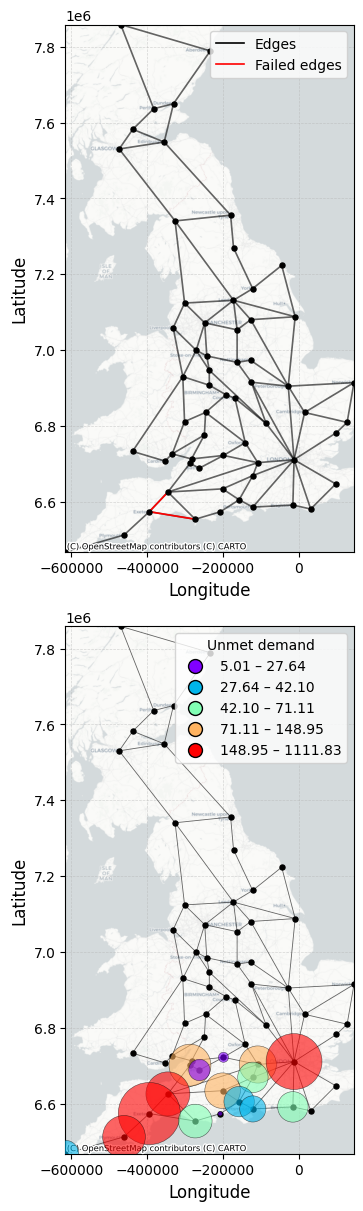

In [24]:
from inputs import input_files_kor, input_files_uk
from shapely import wkt
import json, pandas as pd, geopandas as gpd
from pathlib import Path
import re

input_files = input_files_kor if REGION == "kor" else input_files_uk

nodes_j = json.loads(Path(input_files["nodes"]).read_text(encoding="utf-8"))
node_df = pd.DataFrame(
    [
        {
            "node_id": int(str(nid).lstrip("n")),  # "n1" -> 1
            "lon": float(v["x"]),
            "lat": float(v["y"]),
        }
        for nid, v in nodes_j.items()
    ]
)
edges_j = json.loads(Path(input_files["edges"]).read_text(encoding="utf-8"))

pair_to_id = {}  # {(i_idx, j_idx): base_edge_id}
for eid, data in edges_j.items():
    m = re.match(r"^e(\d+)", str(eid))
    if not m:
        continue
    base_id = int(m.group(1))  

    ni = data["from"]  # "n1"
    nj = data["to"]    # "n2"

    i_idx = int(str(ni).lstrip("n"))
    j_idx = int(str(nj).lstrip("n"))

    if i_idx <= j_idx:
        pair = (i_idx, j_idx)
    else:
        pair = (j_idx, i_idx)

    if pair not in pair_to_id:
        pair_to_id[pair] = base_id

edge_records = []
for (i_idx, j_idx), base_id in pair_to_id.items():
    ni = f"n{i_idx}"
    nj = f"n{j_idx}"

    xi = nodes_j[ni]["x"]; yi = nodes_j[ni]["y"]
    xj = nodes_j[nj]["x"]; yj = nodes_j[nj]["y"]

    wkt_str = f"LINESTRING ({xi} {yi}, {xj} {yj})"
    edge_records.append({"edge_id": base_id, "wkt": wkt_str})

edge_df = pd.DataFrame(edge_records)
edge_df["geometry"] = edge_df["wkt"].astype(str).apply(wkt.loads)

gdf_nodes = gpd.GeoDataFrame(
    node_df,
    geometry=gpd.points_from_xy(node_df["lon"], node_df["lat"]),
    crs="EPSG:4326",
).to_crs(epsg=3857)

gdf_edges = gpd.GeoDataFrame(edge_df, geometry="geometry", crs="EPSG:4326").to_crs(epsg=3857)

df_bubble = pd.DataFrame(
    [(int(str(k).lstrip("n")), float(v)) for k, v in node_unmet_both.items()],
    columns=["node_id", "value"]
)
gdf_bubble = gdf_nodes.merge(df_bubble, on="node_id", how="inner")

vals = gdf_bubble["value"].to_numpy()
xs   = gdf_bubble.geometry.x.values
ys   = gdf_bubble.geometry.y.values

EDGE_LW_BOT = 0.6
EDGE_LW_TOP = 1.2
NODE_MS     = 13
BUBBLE_ALPHA = 0.60
CAMPAL = mpl.cm.rainbow

xmin, ymin, xmax, ymax = gdf_edges.total_bounds
fig, (ax_top, ax_bot) = plt.subplots(nrows=2, ncols=1, figsize=(6, 12), constrained_layout=True)

def draw_base(ax, edge_lw):
    gdf_edges.plot(ax=ax, linewidth=edge_lw, alpha=0.6, color="black", zorder=2)
    gdf_nodes.plot(ax=ax, markersize=NODE_MS, color="black", zorder=4)
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=gdf_edges.crs.to_string(), attribution_size=6)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    ax.set_xlabel("Longitude", fontsize=12); ax.set_ylabel("Latitude", fontsize=12)

draw_base(ax_top, EDGE_LW_TOP)
def base_edge_ids_from_failed_set(fset):
    ids = set()
    for s in fset:
        m = re.match(r'^e(\d+)', str(s).strip())
        if m: ids.add(int(m.group(1)))
    return sorted(ids)

failed_base_ids = base_edge_ids_from_failed_set(failed_set)
gdf_failed = gdf_edges[gdf_edges["edge_id"].isin(failed_base_ids)]
if not gdf_failed.empty:
    gdf_failed.plot(ax=ax_top, color="red", linewidth=EDGE_LW_TOP, alpha=1, zorder=3)
    leg_top = ax_top.legend(
        handles=[
            Line2D([0], [0], color="black", lw=EDGE_LW_TOP, label="Edges"),
            Line2D([0], [0], color="red",   lw=EDGE_LW_TOP, label="Failed edges"),
        ],
        loc="upper right", frameon=True
    )
    leg_top.get_frame().set_alpha(0.8); leg_top.set_zorder(20)

draw_base(ax_bot, EDGE_LW_BOT)

bounds = np.quantile(vals, [0, 0.2, 0.4, 0.6, 0.8, 1.0])
for i in range(1, len(bounds)):
    if bounds[i] <= bounds[i-1]:
        bounds[i] = bounds[i-1] + 1e-9
cmap5 = ListedColormap(CAMPAL(np.linspace(0.0, 1.0, 5)))
norm5 = BoundaryNorm(bounds, cmap5.N, clip=True)
vmin, vmax = float(vals.min()), float(vals.max())
z = np.log1p(vals - vmin) / (np.log1p(vmax - vmin) + 1e-12)
z = np.clip(z, 0.0, 1.0) ** 2.2
sizes = 10.0 + (2000.0 - 10.0) * z

ax_bot.scatter(
    xs, ys, s=sizes, c=vals, cmap=cmap5, norm=norm5,
    alpha=BUBBLE_ALPHA, edgecolor="black", linewidth=0.4, zorder=6, marker="o"
)

color_handles = []
for i in range(len(bounds)-1):
    mid = 0.5 * (bounds[i] + bounds[i+1])
    color = cmap5(norm5(mid))
    label = f"{bounds[i]:.2f} – {bounds[i+1]:.2f}"
    color_handles.append(Line2D([0],[0], marker='o', color='none',
                                markerfacecolor=color, markeredgecolor='black',
                                markersize=10, label=label))
leg = ax_bot.legend(handles=color_handles, title="Unmet demand", loc="upper right", frameon=True)
leg.get_frame().set_alpha(0.8); leg.set_zorder(20)

plt.show()
